<a href="https://colab.research.google.com/github/tsal4/data2000_labs/blob/main/labs/050_decision-trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install graphviz numpy pandas xgboost ydf
# !pip install --force-reinstall "scikit-learn==1.3.1"

# The Palmer Penguins dataset

This lab uses the Palmer Penguins dataset, which contains size measurements for three penguin species:

  - Chinstrap
  - Gentoo
  - Adelie

This is a classification problem — the goal is to predict the species of penguin based on data in the Palmer's Penguins dataset

In [47]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import ydf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## Train an XGBoost Classifier

In [48]:
data = pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/palmer_penguins/penguins.csv")
label = "species"

In [49]:
data["species"] = data["species"].astype("category")
data["island"] = data["island"].astype("category")
data["sex"] = data["sex"].astype("category")

In [50]:
data.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007


In [51]:
le = LabelEncoder()
data_labels = data[label]
data_labels = le.fit_transform(data_labels)

X_train, X_test, y_train, y_test = train_test_split(
    data.drop([label], inplace=False, axis=1),
    data_labels,
    train_size=0.7
)

In [52]:
X_train.shape

(240, 7)

In [53]:
clf = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    objective='multi:softmax')
clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
clf.score(X_test, y_test)

1.0

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


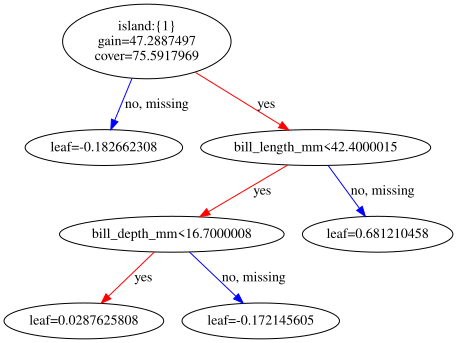

In [55]:
# Get a graph
graph = xgb.to_graphviz(clf, num_trees=1)
graph

In [56]:
preds = clf.predict(X_test)
pred_proba = clf.predict_proba(X_test)
pred_proba = [pred[1] for pred in pred_proba]

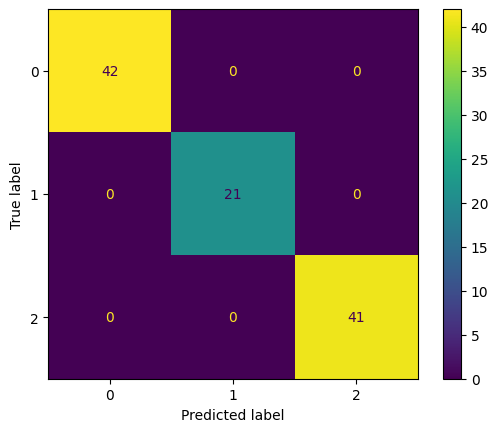

In [57]:
confusion_matrix = confusion_matrix(y_test, preds)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix)

cm_display.plot()
plt.show()

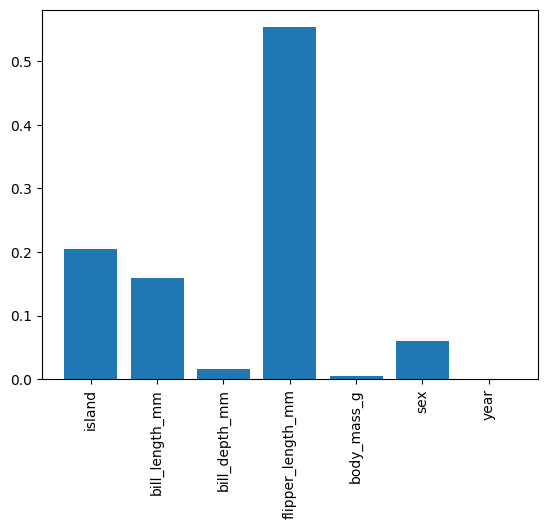

In [58]:
plt.bar(clf.get_booster().feature_names, clf.feature_importances_)
plt.xticks(rotation=90)

plt.show()

## Train a CART (Classification and Regression Trees) Learner

In [59]:
data = pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/palmer_penguins/penguins.csv")
label = "species"

In [60]:
train, test = train_test_split(
    data,
    train_size=0.7
)

In [61]:
train.shape

(240, 8)

In [62]:
model = ydf.CartLearner(label=label).train(train)

Train model on 240 examples
Model trained in 0:00:00.002804


In [63]:
model.plot_tree()

In [64]:
train_evaluation = model.evaluate(train)
print("train accuracy:", train_evaluation.accuracy)

train accuracy: 0.9541666666666667


In [65]:
test_evaluation = model.evaluate(test)
print("test accuracy:", test_evaluation.accuracy)

test accuracy: 0.9230769230769231


### Improve Performance with Custom Hyperparameters

In [66]:
model = ydf.CartLearner(label=label, min_examples=1).train(train)
model.plot_tree()

Train model on 240 examples
Model trained in 0:00:00.002790


In [67]:
print(model.evaluate(test).accuracy)

0.9519230769230769


## Upgrade to a Random Forest Learner

In [68]:
model = ydf.RandomForestLearner(label=label).train(train)
model.plot_tree()

Train model on 240 examples
Model trained in 0:00:00.071861


In [69]:
print("Test accuracy: ", model.evaluate(test).accuracy)

Test accuracy:  0.9615384615384616


# Lab Assignment: Predicting Home Sale Prices with Random Forest and XGBoost

## Overview

In this lab you will work with a rich, real-world dataset of residential home sales in Ames, Iowa. Your goal is to build, tune, and compare two ensemble models — a **Random Forest** and an **XGBoost regressor** — that predict the sale price of a home from a detailed set of structural, locational, and qualitative features. Along the way you will practice the full modeling workflow: exploratory data analysis, thoughtful missing value treatment, feature engineering, hyperparameter tuning, model evaluation, and interpretation using feature importance. You will also run both models as classifiers on a binarized version of the target, giving you direct experience with how the same algorithm behaves across task types.

## The Dataset

The Ames Housing dataset was compiled by Dean De Cock and published in 2011 as a modernized alternative to the aging Boston Housing dataset. It contains records of **2,930 residential property sales** in Ames, Iowa between 2006 and 2010, sourced directly from the Ames City Assessor's Office. Unlike many curated teaching datasets, this one was not pre-cleaned or simplified before release. It reflects the genuine messiness of administrative property records: inconsistent coding, structurally meaningful absences, rare categorical levels, and a target variable with a pronounced right skew.

The dataset contains **80 features** covering virtually every measurable attribute of a residential property — from square footage and number of bathrooms to the type of roof material, the condition of the garage, and whether the property has a pool. This breadth makes it one of the most realistic tabular datasets available for undergraduate instruction.

The primary target variable is **`SalePrice`**: the actual transaction price of the home in US dollars. For the regression tasks in this assignment you will predict `SalePrice` directly. For the classification tasks you will binarize the target at the median sale price, creating a label of **1 (above median)** or **0 (at or below median)**.

### Features

The 80 features fall into several natural categories. What follows is a description of the most important variables and the modeling considerations each raises. You are not required to use every feature — part of this assignment is making deliberate decisions about what to include and why.

#### Lot and Location

**`MSSubClass`** — The building class, encoded as an integer (e.g., 20 = 1-story built after 1946, 70 = 2-story built before 1946). Despite being stored as a number, this is a **nominal categorical** variable. There is no meaningful numeric ordering between building classes, and treating it as continuous would introduce false relationships. You must convert it to a string before encoding.

**`MSZoning`** — General zoning classification: residential low density, commercial, floating village residential, and so on. Categorical. A small number of missing values appear here and should be imputed with the mode.

**`LotFrontage`** — Linear feet of street connected to the property. Continuous, but with roughly 17% missing values — the largest missingness problem in the dataset. The absence is not random: properties without a recorded frontage are often those on irregular lots or in certain neighborhoods. Imputing by **neighborhood median** is a principled strategy worth implementing here.

**`LotArea`** — Lot size in square feet. Continuous, right-skewed, with some extreme outliers representing unusually large parcels. Consider whether a log transformation improves model behavior.

**`Neighborhood`** — Physical location within Ames city limits. This is a nominal categorical with 25 levels, and it is one of the most predictively powerful features in the dataset. Some neighborhoods have very few sales, which creates sparse dummy columns if you one-hot encode naively. Consider target encoding or leave-one-out encoding as alternatives.

#### Building Structure

**`OverallQual`** — Overall material and finish quality, rated on a scale from 1 (very poor) to 10 (very excellent). This is the single strongest predictor of sale price in the dataset. It is recorded as an integer and can be treated as numeric or ordinal. Its relationship with `SalePrice` is approximately exponential — homes rated 8, 9, or 10 are not just incrementally better but categorically more expensive.

**`OverallCond`** — Overall condition of the house, also 1–10. Note that condition and quality are correlated but distinct: a well-maintained older home can have high condition but modest quality.

**`YearBuilt`** — Original construction year. Continuous. Raw year values are valid inputs, but you may find that engineering an **`Age`** feature (current year minus `YearBuilt`) produces a more interpretable coefficient and a slightly more linear relationship with price.

**`YearRemodAdd`** — Year of most recent remodel or addition, or the original construction year if no remodel occurred. Consider engineering a boolean **`WasRemodeled`** flag and/or a **`YearsSinceRemodel`** feature.

**`RoofStyle`** and **`RoofMatl`** — Roof style and material. Both categorical. Most properties have a gable or hip roof with standard shingle material; a handful have unusual materials (e.g., clay tile, membrane) that may be worth flagging as rare levels.

#### Size and Space

**`GrLivArea`** — Above-ground living area in square feet. Continuous and one of the most important numeric predictors. Contains a small number of extreme outliers — two properties with over 4,000 square feet sold for unusually low prices, likely non-standard transactions. The original dataset author explicitly recommends removing these two points (GrLivArea > 4000 with SalePrice < 200000) before modeling.

**`TotalBsmtSF`** — Total square footage of the basement. Continuous. Properties without a basement have a value of 0, which is a legitimate value rather than missing data.

**`1stFlrSF`** and **`2ndFlrSF`** — First and second floor square footage. You may find it useful to engineer a **`TotalSF`** feature summing basement, first floor, and second floor area, as total square footage is often more predictive than its components separately.

**`BedroomAbvGr`**, **`KitchenAbvGr`**, **`TotRmsAbvGrd`** — Room counts above grade. Be aware that total rooms above grade includes bedrooms, so these features are partially collinear. Random forests handle collinearity gracefully; be more thoughtful about this if you extend the work to linear models.

#### Basement Features

**`BsmtQual`**, **`BsmtCond`**, **`BsmtExposure`**, **`BsmtFinType1`**, **`BsmtFinType2`** — Five features describing basement quality, condition, wall exposure, and finish type. All five will be **`NaN`** for properties without a basement. This is a classic example of **structurally missing data**: the absence does not mean unknown, it means inapplicable. You should replace these `NaN` values with a meaningful string such as `"No Basement"` rather than imputing from the distribution of homes that have one.

**`BsmtFinSF1`**, **`BsmtFinSF2`**, **`BsmtUnfSF`** — Finished and unfinished basement square footage subtypes. Also 0 for properties without basements, and genuinely missing for a tiny number of records. Handle the latter with median imputation.

#### Garage Features

**`GarageType`**, **`GarageFinish`**, **`GarageQual`**, **`GarageCond`** — Categorical features describing garage characteristics. Like the basement features, these will be `NaN` for properties with no garage, and should be filled with `"No Garage"`.

**`GarageYrBlt`** — Year the garage was built. Missing for properties without a garage. If you retain this feature, fill garage-less properties with 0 or with the year the house was built; treat it as numeric.

**`GarageCars`** and **`GarageArea`** — Garage capacity in cars and in square feet. These two are highly correlated; you may choose to retain only one or engineer a ratio.

#### Exterior and Finish

**`ExterQual`** and **`ExterCond`** — Exterior material quality and condition, each rated as Ex (Excellent), Gd (Good), TA (Typical/Average), Fa (Fair), or Po (Poor). These and many similar features throughout the dataset use the **same five-level ordinal scale**. You should define a consistent ordinal mapping (`Po=1, Fa=2, TA=3, Gd=4, Ex=5`) and apply it programmatically across all features that share this encoding rather than recoding each one individually.

**`Exterior1st`** and **`Exterior2nd`** — Primary and secondary exterior covering materials. Nominal categorical with many levels; some are rare. Consider grouping uncommon materials into an `"Other"` category.

#### Kitchen, Heating, and Utilities

**`KitchenQual`** — Kitchen quality on the standard five-level ordinal scale. A consistently strong predictor of sale price.

**`HeatingQC`** — Heating system quality and condition, same ordinal scale.

**`CentralAir`** — Whether the home has central air conditioning: Y or N. Binary categorical. Convert to 1/0.

#### Sale Characteristics

**`SaleType`** — Type of sale: warranty deed, court officer deed, contract, and others. Most sales are standard warranty deeds (`WD`). Non-standard sale types can distort the relationship between features and price and are worth flagging.

**`SaleCondition`** — Condition of sale: Normal, Abnormal, Partial (home was not completed at time of sale), Family (sale between family members), Alloca, AdjLand. Non-normal sale conditions, particularly partial and family sales, may not reflect true market prices and are worth examining separately.

### Known Data Quality Issues

This dataset requires more deliberate cleaning than most. The following issues are not exhaustive — part of your job is to find and address others through careful inspection.

- **Structurally missing data.** Features describing basements, garages, pools, fireplaces, masonry veneer, alleys, and fences all use `NaN` to represent the *absence* of that feature, not an unknown value. You must identify all such features and fill them with an appropriate sentinel value (`"No Basement"`, `"No Garage"`, `"No Pool"`, etc.) before any imputation step. Applying mean or mode imputation indiscriminately to these columns is one of the most common and consequential mistakes students make on this dataset.

- **`MSSubClass` stored as integer.** This column will be read as numeric by pandas. You must convert it to string or categorical before encoding.

- **Ordinal features stored as strings.** Many quality and condition columns use labels like `"Ex"`, `"Gd"`, `"TA"`, `"Fa"`, `"Po"`. These need to be mapped to integers to be used as ordered features.

- **Rare categorical levels.** Several nominal features have levels that appear only once or twice across the dataset. These can cause problems during train-test splitting (a level may appear only in the test set) and produce very wide one-hot encoded matrices. Consider grouping rare levels.

- **The two outlier properties.** As noted above, two properties with very large above-ground living area and anomalously low sale prices are widely considered data anomalies. Remove them before modeling.

- **`SalePrice` is right-skewed.** The distribution of sale prices has a long right tail. For regression, consider whether applying a log transformation to `SalePrice` improves your residuals. If you do this, remember to exponentiate your predictions before computing error metrics in the original dollar scale.

## Modeling Concepts

Before beginning, make sure you understand the following ideas at the level needed to discuss your results.

**Random Forest** is an ensemble of decision trees trained on bootstrap samples of the data, each tree using a random subset of features at each split. Predictions are averaged (regression) or majority-voted (classification) across all trees. The key hyperparameters you will tune are `n_estimators` (number of trees), `max_depth` (maximum depth of each tree), `min_samples_leaf` (minimum samples required at a leaf node), and `max_features` (number of features considered at each split).

**XGBoost** is a gradient boosting algorithm that builds trees sequentially, each one correcting the residual errors of the ensemble so far. It is generally more powerful than random forest on tabular data but more sensitive to hyperparameters and more prone to overfitting without regularization. The key hyperparameters you will tune are `n_estimators`, `learning_rate` (how much each tree contributes), `max_depth`, `subsample` (fraction of rows used per tree), `colsample_bytree` (fraction of features used per tree), and `reg_lambda` (L2 regularization term).

Both models provide **feature importances** — estimates of how much each feature contributed to predictive performance. Random forest reports impurity-based importance (mean decrease in Gini or variance). XGBoost offers several importance types; use `weight` (split frequency), `gain` (average improvement per split), or SHAP values if you want to go further. Be aware that impurity-based importances from random forest can be biased toward high-cardinality features.

## Your Tasks

### Part 1: Exploration and Cleaning

1. Load the dataset and produce a complete audit of missing values. Separate features into three categories: structurally missing (absence of a feature), randomly missing (data entry gaps), and the two outlier records. Document how you identified each.

2. Address missing values with appropriate methodologies. Apply median or mode imputation to genuinely missing numeric and categorical features respectively. Justify each decision briefly.

3. Encode all features appropriately: ordinal mappings for quality/condition scales, one-hot encoding for nominal categoricals, and integer conversion for binary features like `CentralAir`. Handle `MSSubClass` correctly.

4. Engineer at least one new feature from existing ones. Candidates include `Age`, `YearsSinceRemodel`, `WasRemodeled`, `TotalSF`, `TotalBaths`, or a ratio of finished to total basement area. For each, explain what real-world property characteristic it is intended to capture.

5. Examine the distribution of `SalePrice`. Apply a log transformation and compare the before and after distributions. Decide whether to model on the raw or log-transformed target and document your reasoning.

### Part 2: Regression Models

6. Split the data into 80% training and 20% test sets. Use a fixed random seed throughout.

7. Train a baseline Random Forest regressor with default hyperparameters. Report RMSE ($\sqrt{\frac{1}{N}\sum_{i=1}^{N}{(y_{i}-\hat{y}_{i}})^{2}}$) and R² on both the training and test sets. A large gap between training and test performance indicates overfitting.

8. **OPTIONALLY:** Tune the Random Forest using either `GridSearchCV` or `RandomizedSearchCV` over at least three hyperparameters. Report your best parameters and the improvement in test RMSE over the baseline.

9. Train a baseline XGBoost regressor with default hyperparameters and report the same metrics.

10. Tune the XGBoost model over at least four hyperparameters. Report your best parameters and test RMSE.

11. Compare your two tuned models directly. Which performs better on test RMSE? Are there categories of homes (by price range, neighborhood, or age) where one model outperforms the other? Compute residuals and plot them against predicted values for both models to check for systematic patterns.

### Part 3: Classification Models

12. Binarize `SalePrice` at the median. Train and tune both a Random Forest classifier and an XGBoost classifier using the same splits. Report accuracy, precision, recall, F1, and AUC-ROC for each.

13. In one paragraph, reflect on how the classification task differs from the regression task in terms of what information is lost, what is gained, and when each framing might be more appropriate in a real business or policy context.

### Part 4: Interpretation

14. Plot the top feature importances for each of your tuned models. Which features appear consistently important across all models? Which are important in one but not others?

15. `OverallQual` and `GrLivArea` are almost always the top two features. Choose two features that appear in your top 10 but that you find surprising or counterintuitive, and offer a substantive explanation for why they might genuinely matter to home buyers or appraisers.

16. Identify at least one feature that you expected to matter more than it did. Propose a hypothesis for why it underperformed — is it correlated with a more powerful feature that absorbs its signal? Is it poorly measured? Does it matter only in a narrow segment of the market?

## Code

In [70]:
import gdown
import glob
import pandas as pd

In [71]:
FILEID="13UjjHgdoBwZkyDFjKXSosJdC7aCRlf0U"
OUTPUT="/content/house-prices.zip"

url = f"https://drive.google.com/uc?id={FILEID}"
gdown.download(url, OUTPUT, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=13UjjHgdoBwZkyDFjKXSosJdC7aCRlf0U
To: /content/house-prices.zip
100%|██████████| 204k/204k [00:00<00:00, 77.2MB/s]


'/content/house-prices.zip'

In [72]:
!unzip /content/house-prices.zip -d /content/house-prices

Archive:  /content/house-prices.zip
replace /content/house-prices/data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/house-prices/data_description.txt  
replace /content/house-prices/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/house-prices/sample_submission.csv  
replace /content/house-prices/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/house-prices/test.csv  
replace /content/house-prices/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/house-prices/train.csv  


In [73]:
files = glob.glob("/content/house-prices/t*.csv")
data = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

## Part 1

In [74]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,NaN
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,NaN
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,NaN
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,NaN
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,NaN


In [75]:
import numpy as np

data.replace('NaN', np.nan, inplace=True)

In [76]:
highly_missing_cols = []

for row in (data.isna().mean() * 100).items():
    if row[1] > 0:
        print(f"{row[0]}:\t{round(row[1], 2)}% missing")
    if row[1] > 0.40:
        highly_missing_cols.append(row[0])

MSZoning:	0.14% missing
LotFrontage:	16.65% missing
Alley:	93.22% missing
Utilities:	0.07% missing
Exterior1st:	0.03% missing
Exterior2nd:	0.03% missing
MasVnrType:	60.5% missing
MasVnrArea:	0.79% missing
BsmtQual:	2.77% missing
BsmtCond:	2.81% missing
BsmtExposure:	2.81% missing
BsmtFinType1:	2.71% missing
BsmtFinSF1:	0.03% missing
BsmtFinType2:	2.74% missing
BsmtFinSF2:	0.03% missing
BsmtUnfSF:	0.03% missing
TotalBsmtSF:	0.03% missing
Electrical:	0.03% missing
BsmtFullBath:	0.07% missing
BsmtHalfBath:	0.07% missing
KitchenQual:	0.03% missing
Functional:	0.07% missing
FireplaceQu:	48.65% missing
GarageType:	5.38% missing
GarageYrBlt:	5.45% missing
GarageFinish:	5.45% missing
GarageCars:	0.03% missing
GarageArea:	0.03% missing
GarageQual:	5.45% missing
GarageCond:	5.45% missing
PoolQC:	99.66% missing
Fence:	80.44% missing
MiscFeature:	96.4% missing
SaleType:	0.03% missing
SalePrice:	49.98% missing


In [77]:
highly_missing_cols.pop(-1)
data = data.drop(highly_missing_cols, axis=1)
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageCars', 'GarageArea',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition', 'SalePrice'],
      dtype='object')

In [78]:
for col, dtype in data.dtypes.items():
    if dtype == "O":
        data[col] = data[col].astype("category")

In [79]:
data["MSSubClass"] = data["MSSubClass"].astype("category")

In [80]:
data.head()

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,NaN
1,1462,20,RL,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,NaN
2,1463,60,RL,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,NaN
3,1464,60,RL,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2010,WD,Normal,NaN
4,1465,120,RL,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,...,0,0,144,0,0,1,2010,WD,Normal,NaN


In [81]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageCars', 'GarageArea',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition', 'SalePrice'],
      dtype='object')

In [82]:
# house age at sale
data["house_age_at_sale"] = data["YrSold"] - data["YearBuilt"]

In [83]:
bathroom_columns = ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']
data["total_bathrooms"] = data.loc[:, bathroom_columns].sum(axis=1)

data = data.drop(bathroom_columns, axis=1)

<Axes: >

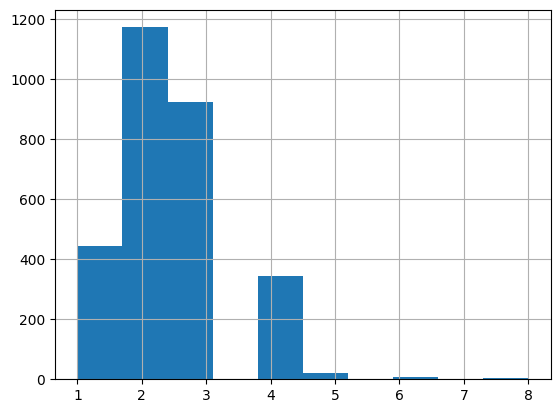

In [84]:
data["total_bathrooms"].hist()

In [85]:
data["BsmtFinSF"] = data.loc[:, ["BsmtFinSF1", "BsmtFinSF2"]].sum(axis=1)
data = data.drop(["BsmtFinSF1", "BsmtFinSF2"], axis=1)

In [86]:
data["BsmtFinSF"].quantile(0.99)

np.float64(1685.8200000000002)

In [87]:
data["BsmtFinSF"].mean()

np.float64(490.8372730387119)

In [88]:
data = data.loc[data["BsmtFinSF"] < 1500, :]

<Axes: >

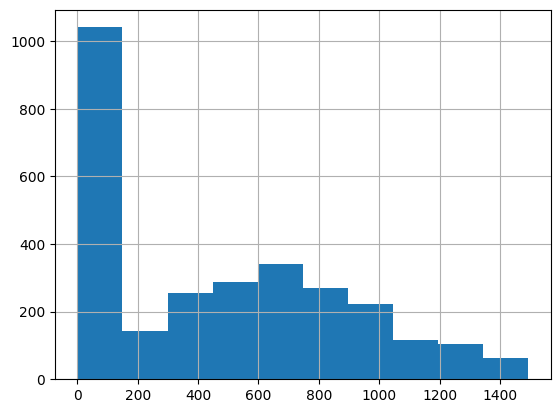

In [89]:
data["BsmtFinSF"].hist()

<Axes: >

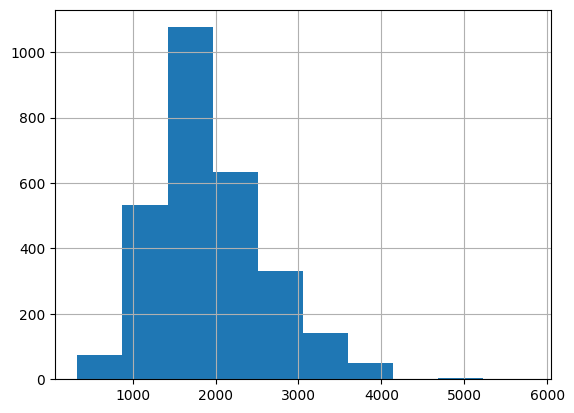

In [90]:
data["TotalSF"] = data.loc[:, ["1stFlrSF", "2ndFlrSF", "BsmtFinSF"]].sum(axis=1)
data["TotalSF"].hist()

<Axes: >

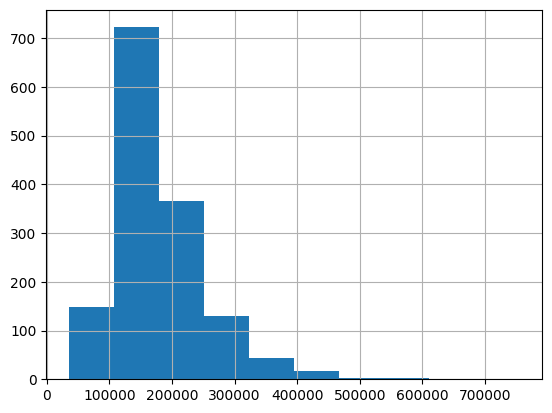

In [91]:
data['SalePrice'].hist()

In [96]:
data['SalePrice'].describe()

,SalePrice
count,1431.000000
mean,177743.982530
std,74616.222643
min,34900.000000
25%,129500.000000
50%,161000.000000
75%,210000.000000
max,755000.000000


In [97]:
data['SalePriceLog'] = np.log(1 + data['SalePrice'])

<Axes: >

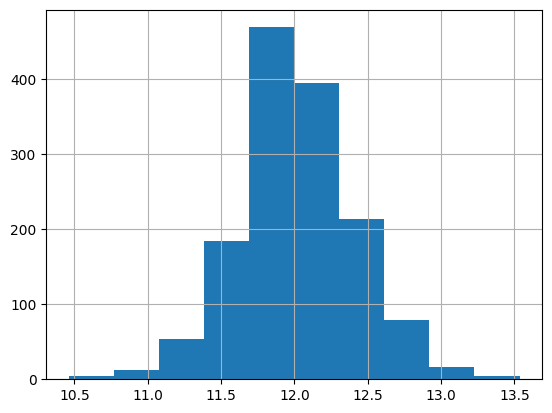

In [98]:
data['SalePriceLog'].hist()

In [99]:
data = data.dropna(subset=['SalePrice'])

In [102]:
data = data.drop('SalePriceLog', axis=1)

## Part 2

In [104]:
train, test = train_test_split(data, test_size=0.2, random_state=5)

In [ ]:
clf = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    objective='multi:softmax')
clf.fit(train)